# 99 - DCGAN on CIFAR-10

**Section:** GANs | **Prereqs:** `GANs/CNN_GANs_FMNIST.ipynb` | **Next:** `RNNs/RNN_class_in_PyTorch.ipynb`

The hardest generation task in this course: 64x64 colour images across ten
completely different object categories, from one unconditional generator.

**Why it is hard.** The generator has to cover ten distinct visual modes with no
label to tell it which one to produce. Expect plausible textures, colours and
shapes rather than recognisable objects - matching real CIFAR-10 needs a
conditional GAN, a much longer run, or a modern architecture (StyleGAN, or a
diffusion model).

**Three things this notebook adds**
- **Resize to 64x64.** Upscaling from 32 gives the convolutional stack more
  spatial steps to work with; DCGAN's proportions assume roughly this size.
- **Refinement convolutions.** Each `ConvTranspose2d` in the generator is followed
  by a stride-1 `Conv2d` (`conv2b`, `conv3b`, `conv4b`). The transposed
  convolution upsamples, the plain one cleans up - this is the standard fix for
  checkerboard artifacts.
- **Smoothed loss curves.** A moving average over the raw per-batch losses, which
  are far too noisy to read directly on a GAN.

**Evaluating generative models is genuinely unsolved.** There is no accuracy here.
The field uses FID and Inception Score, both imperfect; in practice people look at
the samples. When you do, check *variety* as carefully as quality - a beautiful
grid of near-identical images is mode collapse.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchsummary
import sys

In [99]:
# CIFAR-10 resized to 64x64 and normalised per channel to [-1,1].
# Upscaling from 32 gives the convolutional stack more spatial steps; DCGAN's
# proportions assume roughly this size.
transformations = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(64),
    torchvision.transforms.Normalize([.5,.5,.5],[.5,.5,.5])
])

cifar = torchvision.datasets.CIFAR10(root='/', train=True, download=True, transform=transformations)

In [100]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [101]:
# Batch 32 with drop_last=True - required, since bs is hardcoded in the label
# tensors below.
bs = 32

train_loader = DataLoader(cifar, batch_size=bs, drop_last=True, shuffle=True )

In [102]:
a,b = next(iter(train_loader))
a.shape, a.min(), a.max(), a.device

(torch.Size([32, 3, 64, 64]), tensor(-1.), tensor(1.), device(type='cpu'))

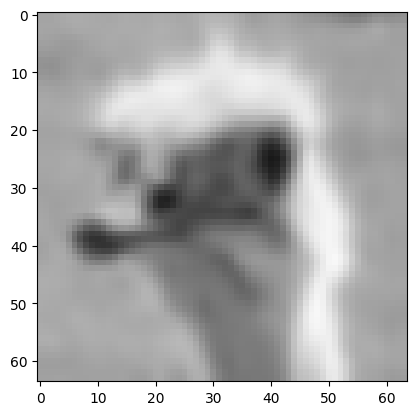

In [103]:
# A real sample, un-normalised for display (* 0.5 + 0.5 inverts the Normalize).
plt.imshow(a[10].permute(1,2,0) * 0.5 + 0.5);

In [104]:
# The discriminator: 3-channel input, 64 -> 32 -> 16 -> 8 -> 4 -> 1.
# The DCGAN architecture rules, from the 2015 paper, and they are worth
# following exactly - GANs are fragile and these were found empirically:
#   - stride-2 convolutions instead of pooling (both directions),
#   - BatchNorm everywhere except the generator's output and the
#     discriminator's input layer,
#   - ReLU in the generator, LeakyReLU(0.2) in the discriminator,
#   - Tanh on the generator's output, matching data normalised to [-1,1],
#   - bias=False on any conv followed by BatchNorm (its shift replaces the bias),
#   - Adam with lr=2e-4 and betas=(0.5, 0.999) - the low beta1 matters, since
#     the usual 0.9 keeps too much momentum from a non-stationary objective.
class discriminatorNet(nn.Module):
  def __init__(self):
    super().__init__()

    # convolution layers
    self.conv1 = nn.Conv2d(  3, 64, 4, 2, 1, bias=False)
    self.conv2 = nn.Conv2d( 64,128, 4, 2, 1, bias=False)
    self.conv3 = nn.Conv2d(128,256, 4, 2, 1, bias=False)
    self.conv4 = nn.Conv2d(256,512, 4, 2, 1, bias=False)
    self.conv5 = nn.Conv2d(512,  1, 4, 1, 0, bias=False)

    # batchnorm
    self.bn2 = nn.BatchNorm2d(128)
    self.bn3 = nn.BatchNorm2d(256)
    self.bn4 = nn.BatchNorm2d(512)

  def forward(self,x):
    x = F.leaky_relu( self.conv1(x) ,.2)
    x = F.leaky_relu( self.conv2(x) ,.2)
    x = self.bn2(x)
    x = F.leaky_relu( self.conv3(x) ,.2)
    x = self.bn3(x)
    x = F.leaky_relu( self.conv4(x) ,.2)
    x = self.bn4(x)
    return torch.sigmoid( self.conv5(x) ).view(-1,1)


dnet = discriminatorNet()
y = dnet(torch.randn(10,3,64,64))
y.shape


torch.Size([10, 1])

torch.Size([10, 3, 64, 64])


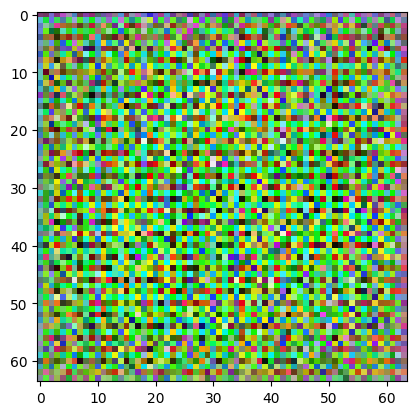

In [105]:
# The generator, with the notable addition: each ConvTranspose2d is followed by
# a stride-1 Conv2d (conv2b, conv3b, conv4b).
# The transposed convolution upsamples and the plain convolution refines - the
# standard fix for checkerboard artifacts, and it produces visibly cleaner
# textures than upsampling alone.
class generatorNet(nn.Module):
    def __init__(self, z_dim=100, out_channels=3):
        super().__init__()

        # Project z to 4x4 spatial feature map
        self.conv1 = nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False)
        self.bn1   = nn.BatchNorm2d(512)

        # 4x4 -> 8x8
        self.conv2 = nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(256)

        # Extra 3x3 conv at 8x8
        self.conv2b = nn.Conv2d(256, 256, 3, 1, 1, bias=False)
        self.bn2b   = nn.BatchNorm2d(256)

        # 8x8 -> 16x16
        self.conv3 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.bn3   = nn.BatchNorm2d(128)

        # Extra 3x3 conv at 16x16
        self.conv3b = nn.Conv2d(128, 128, 3, 1, 1, bias=False)
        self.bn3b   = nn.BatchNorm2d(128)

        # 16x16 -> 32x32
        self.conv4 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.bn4   = nn.BatchNorm2d(64)

        # Extra 3x3 conv at 32x32
        self.conv4b = nn.Conv2d(64, 64, 3, 1, 1, bias=False)
        self.bn4b   = nn.BatchNorm2d(64)

        # 32x32 -> 64x64
        self.conv5 = nn.ConvTranspose2d(64, out_channels, 4, 2, 1, bias=False)

    def forward(self, z):
        x = z.view(-1, z.size(1), 1, 1)

        x = F.relu(self.bn1(self.conv1(x)))

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn3b(self.conv3b(x)))

        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn4b(self.conv4b(x)))

        x = torch.tanh(self.conv5(x))
        return x


gnet = generatorNet()
y = gnet(torch.randn(10,100,1,1))
print(y.shape)
pic = y[0,:,:,:].squeeze().detach().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
plt.imshow(pic);

In [106]:
# DCGAN optimizer settings for both networks.

lossfun = nn.BCELoss()

dnet = discriminatorNet().to(device)
gnet = generatorNet().to(device)

d_optimizer = torch.optim.Adam(dnet.parameters(), lr=.0002, betas=(.5,.999))
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=.0002, betas=(.5,.999))

In [107]:
len(train_loader)


1562

In [108]:
# THE GAN TRAINING LOOP. Two models, two optimizers, one alternating step:
#
# 1. DISCRIMINATOR: show it real images labelled 1 and fake images labelled 0,
#    and minimise BCE on both. It learns to tell them apart.
# 2. GENERATOR: make fresh fakes, run them through the discriminator, and
#    minimise BCE against label 1 - i.e. train the generator to make the
#    discriminator say 'real'.
#
# The label flip in step 2 is the whole trick: the generator has no direct
# target image, only the discriminator's opinion, so 'be more convincing' is
# expressed as 'make D output 1'.
#
# Fakes are REGENERATED between the two steps. Reusing the step-1 fakes would
# backpropagate through a stale graph, and torch would raise.
#
# What to watch: d_loss and g_loss should stay in tension. If d_loss collapses
# to 0 the discriminator won and the generator gets no useful gradient; if
# g_loss collapses the generator found a blind spot. Neither loss going to zero
# is success - equilibrium is.
#
# 40 epochs over CIFAR-10 - the longest run in this course. GANs need time; this
# is still short by the standards of published results.
num_epochs = 40

losses  = []
disDecs = []

for epochi in range(num_epochs):

  for data,_ in train_loader:

    # send data to GPU
    data = data.to(device)

    # create labels for real and fake images
    real_labels = torch.ones(bs,1).to(device)
    fake_labels = torch.zeros(bs,1).to(device)



    ### ---------------- Train the discriminator ---------------- ###

    # forward pass and loss for REAL pictures
    pred_real   = dnet(data)                     # output of discriminator
    d_loss_real = lossfun(pred_real,real_labels) # all labels are 1

    # forward pass and loss for FAKE pictures

    fake_data   = torch.randn(bs,100,1,1).to(device) # random numbers to seed the generator
    fake_images = gnet(fake_data)       # output of generator

    pred_fake   = dnet(fake_images)                         # pass through discriminator
    d_loss_fake = lossfun(pred_fake,fake_labels)            # all labels are 0

    # collect loss (using combined losses)
    d_loss = d_loss_real + d_loss_fake

    # backprop
    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()



    ### ---------------- Train the generator ---------------- ###

    # create fake images and compute loss
    fake_images = gnet( torch.randn(bs,100,1,1).to(device) )
    pred_fake   = dnet(fake_images)

    # compute loss
    g_loss = lossfun(pred_fake,real_labels)

    # backprop
    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()


    # collect losses and discriminator decisions
    losses.append([d_loss.item(),g_loss.item()])

    d1 = torch.mean((pred_real>.5).float()).detach().cpu()
    d2 = torch.mean((pred_fake>.5).float()).detach().cpu()
    disDecs.append([d1,d2])

  # print out a status message
  msg = f'Finished epoch {epochi+1}/{num_epochs}'
  sys.stdout.write('\r' + msg)


# convert performance from list to numpy array
losses  = np.array(losses)
disDecs = np.array(disDecs)

Finished epoch 40/40

In [109]:
# A moving-average smoother. GAN losses are far too noisy per batch to read
# directly, and the trend is the only informative part.
def smooth(x,k=15):
  return np.convolve(x,np.ones(k)/k,mode='same')


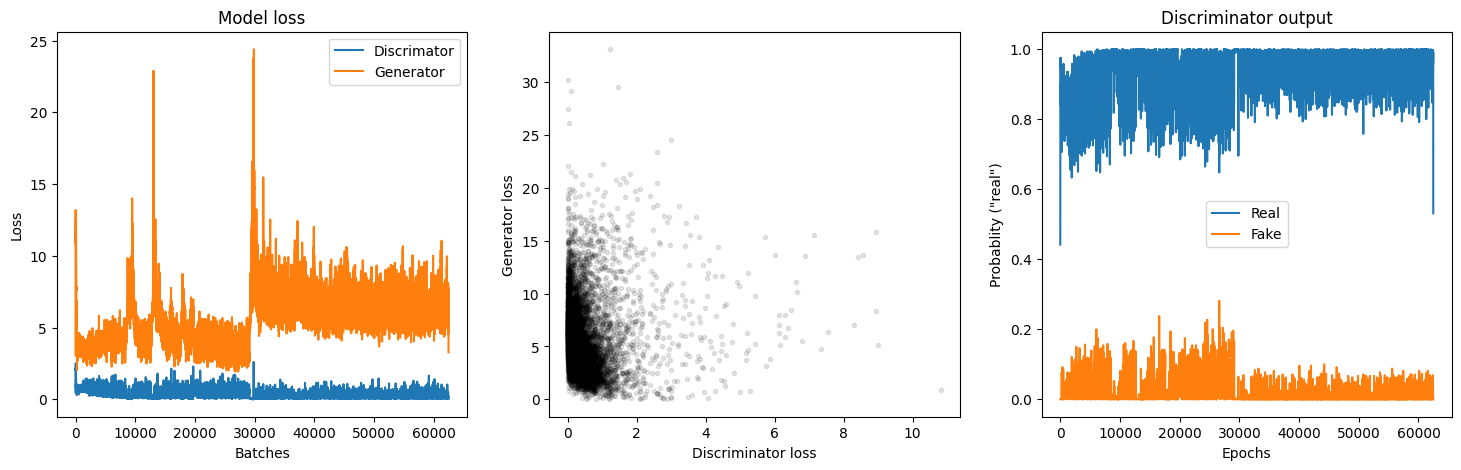

In [110]:
# The three GAN diagnostics:
# LEFT   - both losses over time. Look for sustained oscillation, not
#          convergence. A GAN that 'converges' has usually collapsed.
# MIDDLE - discriminator loss against generator loss. A diagonal cloud means the
#          two are trading blows; a point in one corner means one has won.
# RIGHT  - the discriminator's decisions on real and fake. At equilibrium both
#          approach 0.5: it can no longer tell them apart. That is the target,
#          and it is the closest thing a GAN has to an accuracy metric.
#
# On CIFAR expect plausible textures and colours rather than recognisable
# objects. Ten visual modes from one unconditional generator is genuinely hard -
# recognisable output needs a conditional GAN, far more training, or a modern
# architecture.
# When judging samples, check VARIETY as hard as quality: a grid of beautiful
# near-identical images is mode collapse, not success.

fig,ax = plt.subplots(1,3,figsize=(18,5))

ax[0].plot(smooth(losses[:,0]))
ax[0].plot(smooth(losses[:,1]))
ax[0].set_xlabel('Batches')
ax[0].set_ylabel('Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator','Generator'])
# ax[0].set_xlim([1500,2000])

ax[1].plot(losses[::5,0],losses[::5,1],'k.',alpha=.1)
ax[1].set_xlabel('Discriminator loss')
ax[1].set_ylabel('Generator loss')

ax[2].plot(smooth(disDecs[:,0]))
ax[2].plot(smooth(disDecs[:,1]))
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probablity ("real")')
ax[2].set_title('Discriminator output')
ax[2].legend(['Real','Fake'])

plt.show()


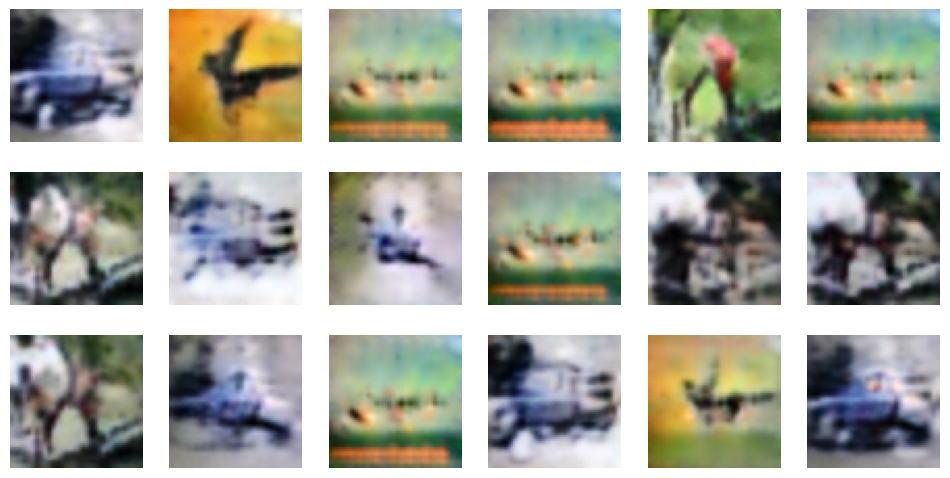

In [111]:
# generate the images from the generator network
gnet.eval()
fake_data = gnet( torch.randn(bs,100,1,1).to(device) ).cpu()

# and visualize...
fig,axs = plt.subplots(3,6,figsize=(12,6))
for i,ax in enumerate(axs.flatten()):
  pic = fake_data[i,:,].detach().squeeze().numpy().transpose((1,2,0))
  pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
  ax.imshow(pic,cmap='gray')
  ax.axis('off')

plt.show()